# Time Series Forecasting using ARIMA, SARIMA & Prophet

## Objective
Forecast future monthly closing prices using historical stock price data.
We compare classical statistical models (ARIMA, SARIMA) with a modern additive model (Prophet).


In [57]:
# Checking entry point
import sys
print(sys.executable)

B:\Training\BIA\Projects\venv\Scripts\python.exe


In [58]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from prophet import Prophet

from sklearn import metrics


In [59]:
# Load data
data = pd.read_csv(r"../data/yahoo_stock.csv")
data.head()


,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


In [60]:
# Data back-up & Summary
# Back-up
df = data.copy()

# Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1825 non-null   object 
 1   High       1825 non-null   float64
 2   Low        1825 non-null   float64
 3   Open       1825 non-null   float64
 4   Close      1825 non-null   float64
 5   Volume     1825 non-null   float64
 6   Adj Close  1825 non-null   float64
dtypes: float64(6), object(1)
memory usage: 99.9+ KB


### Meta Data

In [61]:
# Rows & Columns
print("Count of Rows: ", df.shape[0])
print("\nCount of Columns: ", df.shape[1])

Count of Rows:  1825

Count of Columns:  7


In [62]:
# Column Details
print("All Columns: \n")
print(df.columns.to_list())

All Columns: 

['Date', 'High', 'Low', 'Open', 'Close', 'Volume', 'Adj Close']


In [63]:
# Duplicates
print("Count of duplicates:", df.duplicated().sum())
print("\nDuplicate Rows: \n")
df[df.duplicated()]

Count of duplicates: 0

Duplicate Rows: 



,Date,High,Low,Open,Close,Volume,Adj Close


In [64]:
# Data Types
print("Data Type details: \n")
df.dtypes

Data Type details: 



Date          object
High         float64
Low          float64
Open         float64
Close        float64
Volume       float64
Adj Close    float64
dtype: object

In [65]:
# Null Value details:
df.isnull().sum()

Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Adj Close    0
dtype: int64

In [66]:
# Ststistical Summary
df.describe(include = "all")

,Date,High,Low,Open,Close,Volume,Adj Close
count,1825,1825.000000,1825.000000,1825.000000,1825.000000,1.825000e+03,1825.000000
unique,1825,NaN,NaN,NaN,NaN,NaN,NaN
top,2015-11-23,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2660.718673,2632.817580,2647.704751,2647.856284,3.869627e+09,2647.856284
std,NaN,409.680853,404.310068,407.169994,407.301177,1.087593e+09,407.301177
min,NaN,1847.000000,1810.099976,1833.400024,1829.079956,1.296540e+09,1829.079956
25%,NaN,2348.350098,2322.250000,2341.979980,2328.949951,3.257950e+09,2328.949951
50%,NaN,2696.250000,2667.840088,2685.489990,2683.340088,3.609740e+09,2683.340088
75%,NaN,2930.790039,2900.709961,2913.860107,2917.520020,4.142850e+09,2917.520020


### Data Pre-processing

In [67]:
# Change data type of Date column
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


In [68]:
# Monthly aggregation (use Close price mean)
monthly_data = (
    df
    .groupby(pd.Grouper(key='Date', freq='M'))['Close']
    .mean()
    .reset_index()
)

monthly_data.columns = ['ds', 'y']
monthly_data.head()


C:\Users\catch\AppData\Local\Temp\ipykernel_6984\913559040.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key='Date', freq='M'))['Close']


,ds,y
0,2015-11-30,2088.026306
1,2015-12-31,2051.352913
2,2016-01-31,1927.887408
3,2016-02-29,1902.567938
4,2016-03-31,2023.688059


### Exploratory Data Analysis (EDA)

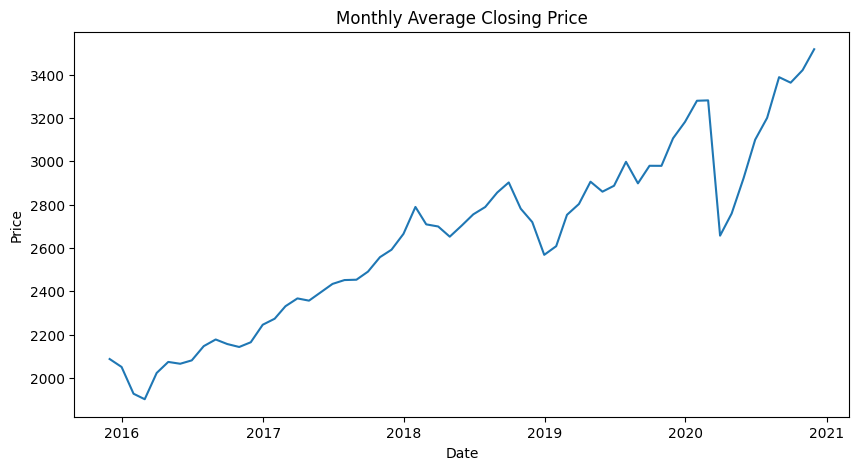

In [69]:
plt.figure(figsize=(10,5))
plt.plot(monthly_data['ds'], monthly_data['y'])
plt.title("Monthly Average Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

### Stationarity Check (ADF Test)

In [70]:
adf_result = adfuller(monthly_data['y'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -0.3973774410617042
p-value: 0.9105357307992307


#### Note:
If p-value > 0.05, series is non-stationary → differencing required.

### ACF & PCF Analysis

<Figure size 1200x400 with 0 Axes>

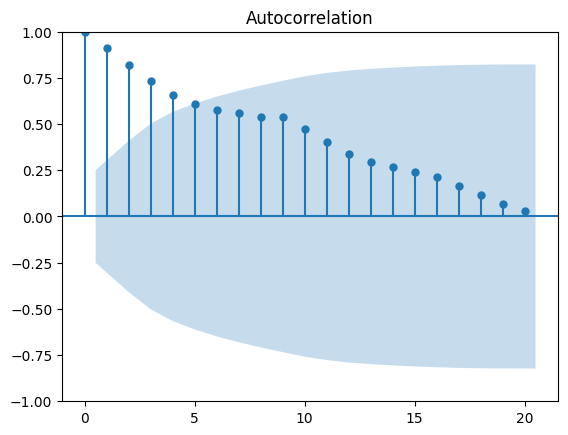

In [71]:
# ACF
plt.figure(figsize=(12,4))
plot_acf(monthly_data['y'], lags=20)
plt.show()


<Figure size 1200x400 with 0 Axes>

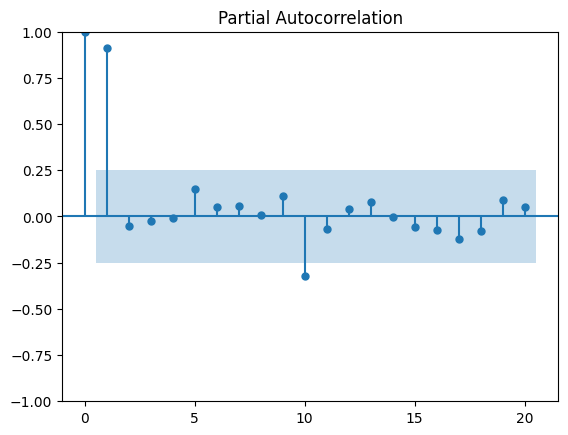

In [72]:
# PCF
plt.figure(figsize=(12,4))
plot_pacf(monthly_data['y'], lags=20)
plt.show()

### Train-Test Split

In [73]:
train = monthly_data.iloc[:-12]
test  = monthly_data.iloc[-12:]

### Arima Model

In [74]:
arima_model = ARIMA(train['y'], order=(1,1,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=12)

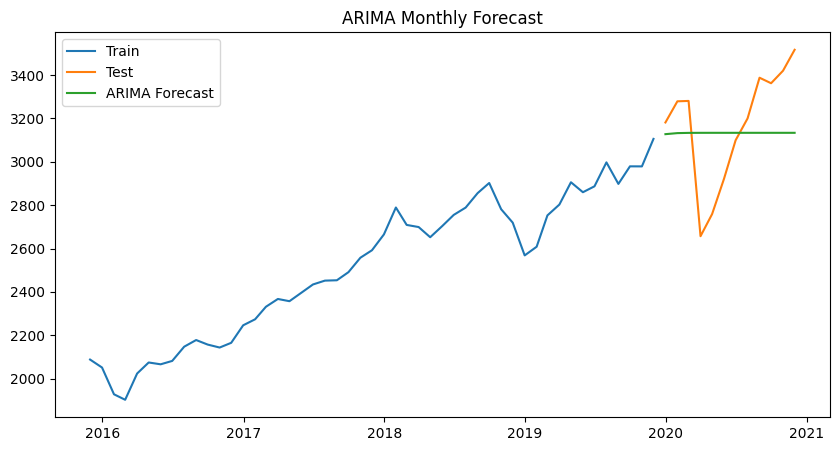

In [75]:
# Visulize ARIMA forecast
plt.figure(figsize=(10,5))
plt.plot(train['ds'], train['y'], label='Train')
plt.plot(test['ds'], test['y'], label='Test')
plt.plot(test['ds'], arima_forecast, label='ARIMA Forecast')
plt.legend()
plt.title("ARIMA Monthly Forecast")
plt.show()

### SARIMA Model

In [76]:
sarima_model = SARIMAX(
    train['y'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()
sarima_forecast = sarima_fit.forecast(steps=12)


B:\Training\BIA\Projects\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


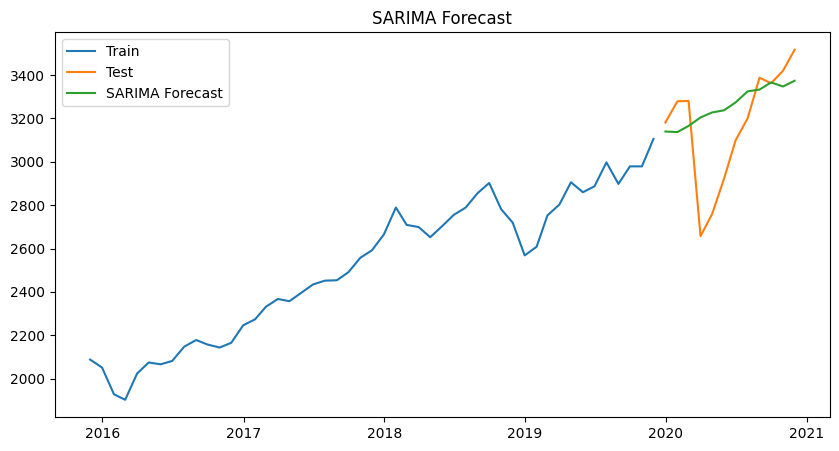

In [77]:
# Visualize SARIMA Forecast
plt.figure(figsize=(10,5))
plt.plot(train['ds'], train['y'], label='Train')
plt.plot(test['ds'], test['y'], label='Test')
plt.plot(test['ds'], sarima_forecast, label='SARIMA Forecast')
plt.legend()
plt.title("SARIMA Forecast")
plt.show()

### Prophet Model

In [81]:
prophet_model = Prophet()
prophet_model.fit(train)

future = prophet_model.make_future_dataframe(periods=12, freq='M')
prophet_forecast = prophet_model.predict(future)

14:33:34 - cmdstanpy - INFO - Chain [1] start processing
14:33:35 - cmdstanpy - INFO - Chain [1] done processing
B:\Training\BIA\Projects\venv\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


### Plot prophet forecast

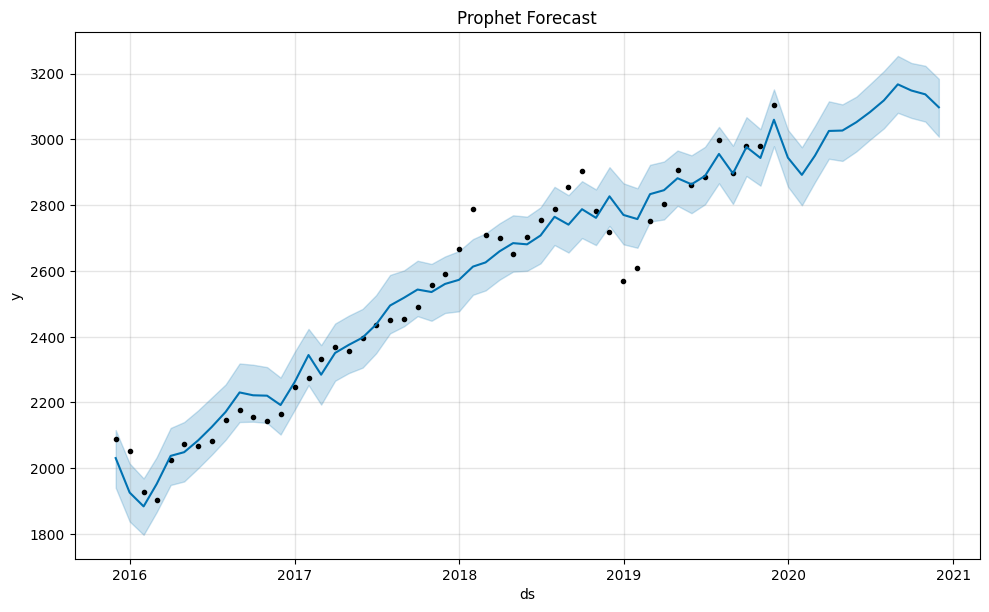

In [82]:
prophet_model.plot(prophet_forecast)
plt.title("Prophet Forecast")
plt.show()

### Model Evaluation

In [83]:
# ARIMA Metrics
mae_arima = metrics.mean_absolute_error(test['y'], arima_forecast)
rmse_arima = metrics.root_mean_squared_error(test['y'], arima_forecast)

# SARIMA Metrics
mae_sarima = metrics.mean_absolute_error(test['y'], sarima_forecast)
rmse_sarima = metrics.root_mean_squared_error(test['y'], sarima_forecast)

# Prophet Metrics
prophet_preds = prophet_forecast.tail(12)['yhat'].values
mae_prophet = metrics.mean_absolute_error(test['y'], prophet_preds)
rmse_prophet = metrics.root_mean_squared_error(test['y'], prophet_preds)

print("ARIMA  MAE:", mae_arima, "RMSE:", rmse_arima)
print("SARIMA MAE:", mae_sarima, "RMSE:", rmse_sarima)
print("Prophet MAE:", mae_prophet, "RMSE:", rmse_prophet)


ARIMA  MAE: 221.9934391045713 RMSE: 259.780853539754
SARIMA MAE: 183.6811142984856 RMSE: 246.4972263201094
Prophet MAE: 246.3683616340436 RMSE: 273.4206721009453


## Conclusion
- Monthly aggregation reduced daily noise.
- ARIMA captured short-term trend.
- SARIMA improved performance by modeling seasonality.
- Prophet handled trend and seasonality robustly.
- SARIMA / Prophet performed best based on RMSE.

## Business Insight
Monthly forecasting is more stable and suitable for long-term planning.
